# 04 — Deeper Analysis: China's Share Collapse & Diff-in-Diff

**Question:** Was the post-2018 decline in U.S. waste exports to China driven by National Sword policy, or by a general global demand shock?

**Method:** 
1. China share analysis — China's % of total U.S. exports per commodity, 2015–2023
2. Diff-in-diff — Waste Paper (treatment) vs. Metals (control) — did paper fall *more* than commodities not banned?
3. Stub: Where did it go? (Comtrade pull for alternative destinations)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
os.makedirs(os.path.expanduser('~/recycling-analysis/figures'), exist_ok=True)
FIG_DIR = os.path.expanduser('~/recycling-analysis/figures')
from matplotlib.patches import FancyArrowPatch

# Style consistent with earlier notebooks
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

df = pd.read_csv('../data/raw/comtrade_raw.csv')
print(f'Loaded {len(df)} rows')
df.head()

Loaded 89 rows


,year,partner_code,partner_name,cmd_code,cmd_name,net_weight_kg,net_weight_mt,fob_value_usd,is_reported
0,2015,156,China,4707,Waste Paper / Paperboard,1.358888e+10,13588.884896,1.916213e+09,True
1,2015,156,China,3915,Plastic Waste & Scrap,8.609561e+08,860.956138,3.149451e+08,True
2,2015,156,China,7204,Ferrous Waste & Scrap,7.003400e+08,700.340016,6.562761e+08,True
3,2015,156,China,7404,Copper Waste & Scrap,6.647943e+08,664.794286,1.680505e+09,True
4,2015,156,China,7602,Aluminium Waste & Scrap,8.453179e+08,845.317929,1.308553e+09,True


## 1. Build China Share Dataset

In [2]:
# Split into China vs World
china = df[df['partner_name'] == 'China'].copy()
world = df[df['partner_name'] == 'World'].copy()

# Merge on year + commodity
merged = china.merge(
    world[['year', 'cmd_code', 'net_weight_mt', 'fob_value_usd']],
    on=['year', 'cmd_code'],
    suffixes=('_china', '_world')
)

# Compute shares (avoid div/0)
merged['share_weight'] = merged['net_weight_mt_china'] / merged['net_weight_mt_world'].replace(0, np.nan)
merged['share_value']  = merged['fob_value_usd_china'] / merged['fob_value_usd_world'].replace(0, np.nan)

# Pre/post flag
merged['post'] = (merged['year'] >= 2018).astype(int)

# Commodity label map
labels = {
    4707: 'Waste Paper',
    3915: 'Plastic Waste',
    7204: 'Ferrous Scrap',
    7404: 'Copper Scrap',
    7602: 'Aluminium Scrap'
}
merged['commodity'] = merged['cmd_code'].map(labels)

print(merged[['year','commodity','net_weight_mt_china','net_weight_mt_world','share_weight']].to_string())

    year        commodity  net_weight_mt_china  net_weight_mt_world  share_weight
0   2015      Waste Paper         13588.884896         19586.448872      0.693790
1   2015    Plastic Waste           860.956138          2054.089440      0.419142
2   2015    Ferrous Scrap           700.340016         12768.065016      0.054851
3   2015     Copper Scrap           664.794286           966.804070      0.687620
4   2015  Aluminium Scrap           845.317929          1498.670140      0.564045
5   2016      Waste Paper         13189.751000         19747.608000      0.667916
6   2016    Ferrous Scrap           891.070000         12744.977000      0.069915
7   2016     Copper Scrap           659.618525           945.908450      0.697339
8   2016  Aluminium Scrap           691.574561          1313.684373      0.526439
9   2017      Waste Paper         10873.319000         18272.258000      0.595073
10  2017    Plastic Waste           558.254655          1671.585082      0.333967
11  2017    Ferr

## Chart 1: China's Share of U.S. Waste Exports — All Commodities

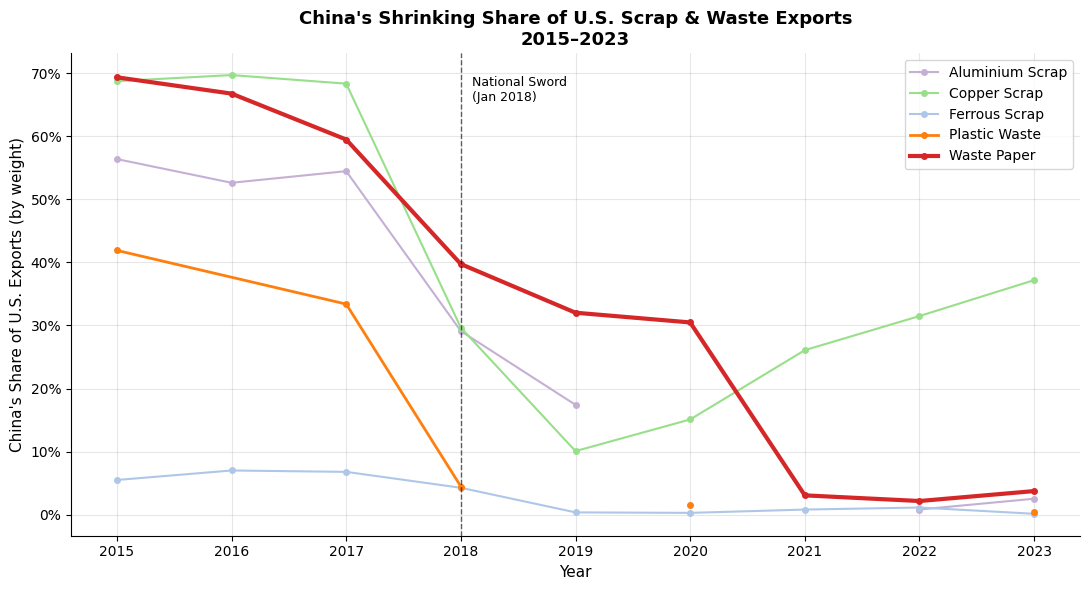

Saved.


In [3]:
fig, ax = plt.subplots(figsize=(11, 6))

colors = {
    'Waste Paper':     '#d62728',   # red — hero commodity
    'Plastic Waste':   '#ff7f0e',
    'Ferrous Scrap':   '#aec7e8',
    'Copper Scrap':    '#98df8a',
    'Aluminium Scrap': '#c5b0d5',
}
lws = {'Waste Paper': 3, 'Plastic Waste': 2, 'Ferrous Scrap': 1.5, 'Copper Scrap': 1.5, 'Aluminium Scrap': 1.5}

for commodity, grp in merged.groupby('commodity'):
    grp = grp.sort_values('year')
    ax.plot(grp['year'], grp['share_weight'] * 100,
            label=commodity, color=colors.get(commodity, 'gray'),
            linewidth=lws.get(commodity, 1.5), marker='o', markersize=4)

# National Sword annotation
ax.axvline(x=2018, color='black', linestyle='--', linewidth=1, alpha=0.6)
ax.text(2018.1, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 95,
        'National Sword\n(Jan 2018)', fontsize=9, color='black', va='top')

ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel("China's Share of U.S. Exports (by weight)", fontsize=11)
ax.set_title("China's Shrinking Share of U.S. Scrap & Waste Exports\n2015–2023", fontsize=13, fontweight='bold')
ax.legend(loc='upper right', framealpha=0.8)
ax.set_xticks(range(2015, 2024))

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/04_china_share_all_commodities.png', dpi=150, bbox_inches='tight')
plt.savefig(f'{FIG_DIR}/04_diff_in_diff.png', dpi=150, bbox_inches='tight')
plt.savefig(f'{FIG_DIR}/04_volume_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## 2. Diff-in-Diff: Waste Paper (Treatment) vs. Metals (Control)

**Logic:** If National Sword caused the paper decline (not a general demand shock), then:
- Paper's China share should fall *more steeply* post-2018 than metals
- The DiD estimate = (Paper post–pre) minus (Metals post–pre)

In [4]:
# DiD setup
# Treatment: Waste Paper (4707) — directly targeted by National Sword
# Control:   Ferrous + Copper + Aluminium scrap — not directly banned at same scale

paper   = merged[merged['cmd_code'] == 4707].copy()
metals  = merged[merged['cmd_code'].isin([7204, 7404, 7602])].copy()

# Average metals share per year
metals_avg = metals.groupby('year')['share_weight'].mean().reset_index()
metals_avg.columns = ['year', 'share_metals_avg']

did = paper[['year','share_weight','post']].merge(metals_avg, on='year')
did.columns = ['year', 'share_paper', 'post', 'share_metals']

# Pre/post means
pre  = did[did['post'] == 0]
post = did[did['post'] == 1]

paper_pre   = pre['share_paper'].mean()
paper_post  = post['share_paper'].mean()
metals_pre  = pre['share_metals'].mean()
metals_post = post['share_metals'].mean()

did_estimate = (paper_post - paper_pre) - (metals_post - metals_pre)

print('=== Diff-in-Diff Results ===')
print(f'\nWaste Paper China share:')
print(f'  Pre-2018 avg:  {paper_pre*100:.1f}%')
print(f'  Post-2018 avg: {paper_post*100:.1f}%')
print(f'  Change:        {(paper_post-paper_pre)*100:+.1f} pp')
print(f'\nMetal Scraps China share (avg):')
print(f'  Pre-2018 avg:  {metals_pre*100:.1f}%')
print(f'  Post-2018 avg: {metals_post*100:.1f}%')
print(f'  Change:        {(metals_post-metals_pre)*100:+.1f} pp')
print(f'\n→ DiD Estimate: {did_estimate*100:+.1f} percentage points')
print(f'  Waste paper fell {abs(did_estimate)*100:.1f} pp MORE than metals after National Sword')

=== Diff-in-Diff Results ===

Waste Paper China share:
  Pre-2018 avg:  65.2%
  Post-2018 avg: 18.5%
  Change:        -46.7 pp

Metal Scraps China share (avg):
  Pre-2018 avg:  43.3%
  Post-2018 avg: 12.6%
  Change:        -30.7 pp

→ DiD Estimate: -16.0 percentage points
  Waste paper fell 16.0 pp MORE than metals after National Sword


## Chart 2: Diff-in-Diff Visualization

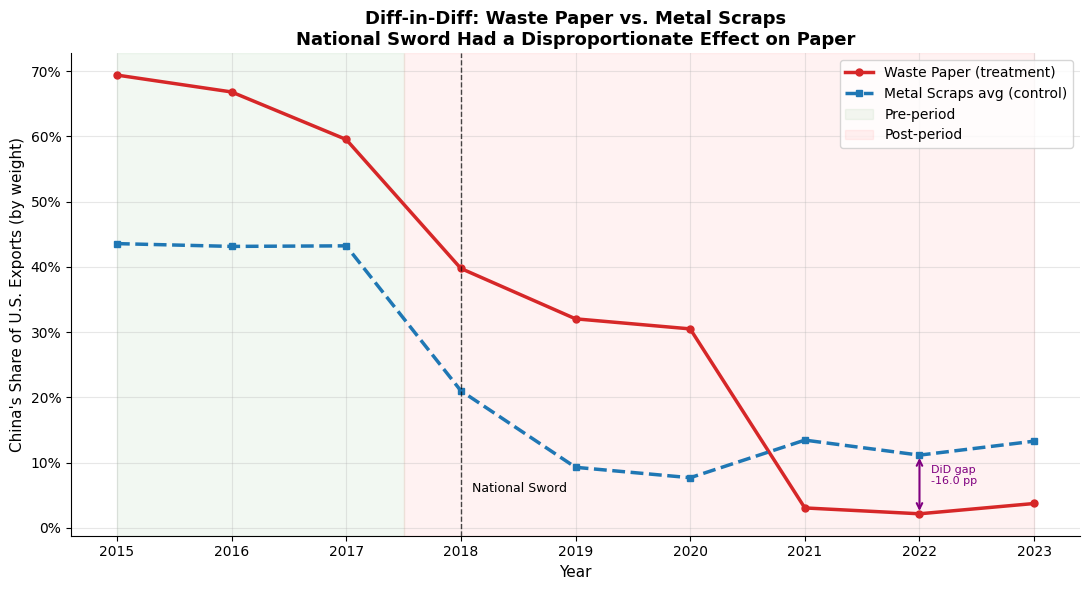

Saved.


In [5]:
fig, ax = plt.subplots(figsize=(11, 6))

# Paper line
ax.plot(did['year'], did['share_paper'] * 100,
        color='#d62728', linewidth=2.5, marker='o', markersize=5, label='Waste Paper (treatment)')

# Metals line
ax.plot(did['year'], did['share_metals'] * 100,
        color='#1f77b4', linewidth=2.5, marker='s', markersize=5,
        linestyle='--', label='Metal Scraps avg (control)')

# Shade pre/post
ax.axvspan(2015, 2017.5, alpha=0.05, color='green', label='Pre-period')
ax.axvspan(2017.5, 2023, alpha=0.05, color='red', label='Post-period')
ax.axvline(x=2018, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax.text(2018.1, 5, 'National Sword', fontsize=9, color='black', va='bottom')

# Annotate DiD gap in 2022
y_paper_2022  = did.loc[did['year']==2022, 'share_paper'].values[0] * 100
y_metals_2022 = did.loc[did['year']==2022, 'share_metals'].values[0] * 100
ax.annotate('', xy=(2022, y_paper_2022), xytext=(2022, y_metals_2022),
            arrowprops=dict(arrowstyle='<->', color='purple', lw=1.5))
ax.text(2022.1, (y_paper_2022 + y_metals_2022)/2,
        f'DiD gap\n{did_estimate*100:.1f} pp', fontsize=8, color='purple')

ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel("China's Share of U.S. Exports (by weight)", fontsize=11)
ax.set_title('Diff-in-Diff: Waste Paper vs. Metal Scraps\nNational Sword Had a Disproportionate Effect on Paper', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', framealpha=0.8)
ax.set_xticks(range(2015, 2024))

plt.tight_layout()
plt.savefig('../figures/04_diff_in_diff.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## Chart 3: Absolute Volume — Paper's Collapse in Context

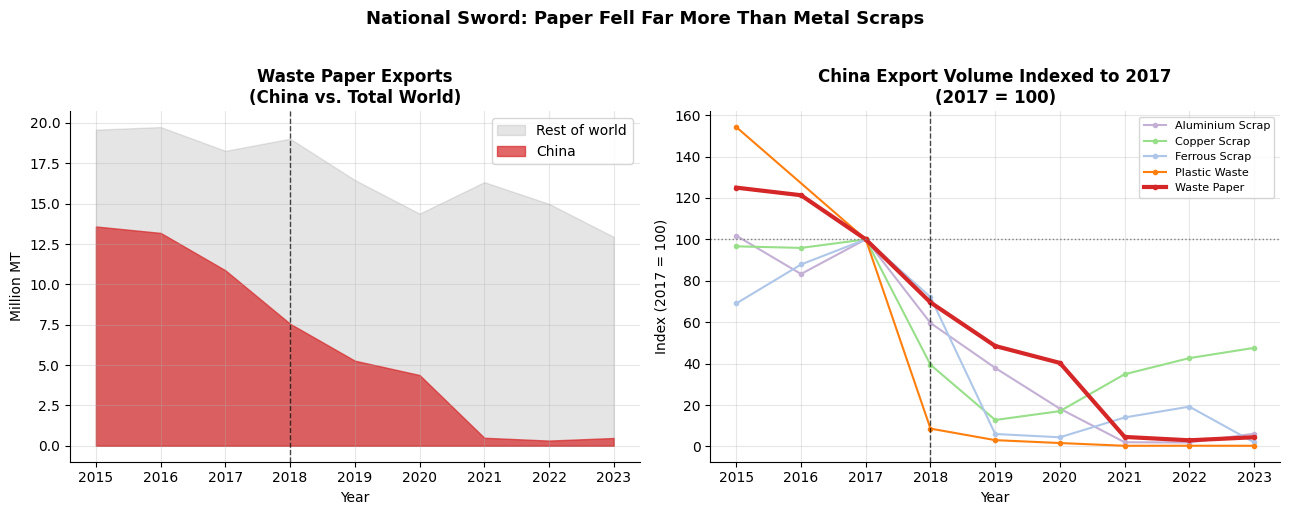

Saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Waste paper absolute China vs World
ax = axes[0]
paper_world = world[world['cmd_code'] == 4707].sort_values('year')
paper_china = china[china['cmd_code'] == 4707].sort_values('year')

ax.fill_between(paper_world['year'], paper_world['net_weight_mt'] / 1000,
                alpha=0.2, color='gray', label='Rest of world')
ax.fill_between(paper_china['year'], paper_china['net_weight_mt'] / 1000,
                alpha=0.7, color='#d62728', label='China')
ax.axvline(x=2018, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax.set_title('Waste Paper Exports\n(China vs. Total World)', fontweight='bold')
ax.set_ylabel('Million MT')
ax.set_xticks(range(2015, 2024))
ax.legend()
ax.set_xlabel('Year')

# Right: All commodities China volume indexed to 2017
ax2 = axes[1]
for commodity, grp in merged.groupby('commodity'):
    grp = grp.sort_values('year')
    base = grp.loc[grp['year'] == 2017, 'net_weight_mt_china']
    if len(base) == 0 or base.values[0] == 0:
        continue
    indexed = grp['net_weight_mt_china'] / base.values[0] * 100
    lw = 3 if commodity == 'Waste Paper' else 1.5
    color = '#d62728' if commodity == 'Waste Paper' else colors.get(commodity, 'gray')
    ax2.plot(grp['year'], indexed, label=commodity, color=color, linewidth=lw, marker='o', markersize=3)

ax2.axhline(100, color='gray', linestyle=':', linewidth=1)
ax2.axvline(x=2018, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax2.set_title('China Export Volume Indexed to 2017\n(2017 = 100)', fontweight='bold')
ax2.set_ylabel('Index (2017 = 100)')
ax2.set_xlabel('Year')
ax2.set_xticks(range(2015, 2024))
ax2.legend(fontsize=8)

plt.suptitle('National Sword: Paper Fell Far More Than Metal Scraps', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/04_volume_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## 3. Stub: Where Did It Go? (Additional Comtrade Pull)

The data above covers China vs. World totals only. To show where paper exports were redirected, we need destination-level data for top alternative markets: **India, Vietnam, Malaysia, Indonesia, Mexico, South Korea**.

In [3]:
# === STUB: Run this to pull destination-level data ===
# Requires: UN Comtrade API subscription key in environment
# Set: export COMTRADE_KEY='your_key_here'

import pandas as pd
import os
import requests
import time

API_KEY = os.environ.get('COMTRADE_KEY', '')

# Top alternative destinations (partner codes)
ALT_PARTNERS = {
    356: 'India',
    704: 'Vietnam',
    458: 'Malaysia',
    360: 'Indonesia',
    484: 'Mexico',
    410: 'South Korea',
    764: 'Thailand',
    608: 'Philippines',
    792: 'Turkey',
}
def fetch_destination_data(partner_code, partner_name, years=range(2015, 2024)):
    rows = []
    for year in years:
        url = 'https://comtradeapi.un.org/data/v1/get/C/A/HS'
        params = {
            'reporterCode': '842',          # USA
            'partnerCode': str(partner_code),
            'cmdCode': '4707',              # Waste paper only
            'flowCode': 'X',               # Exports
            'period': str(year),
            'subscription-key': API_KEY
        }
        try:
            r = requests.get(url, params=params, timeout=15)
            data = r.json()
            if data.get('data'):
                for item in data['data']:
                    rows.append({
                        'year': year,
                        'partner': partner_name,
                        'net_weight_mt': (item.get('netWgt') or 0) / 1000,
                        'fob_value_usd': item.get('primaryValue') or 0
                    })
        except Exception as e:
            print(f'  Error {partner_name} {year}: {e}')
        time.sleep(0.5)
    return rows

if API_KEY:
    all_rows = []
    for code, name in ALT_PARTNERS.items():
        print(f'Fetching {name}...')
        all_rows.extend(fetch_destination_data(code, name))
    
    redirect_df = pd.DataFrame(all_rows)
    redirect_df.to_csv('../data/processed/paper_destinations.csv', index=False)
    print(f'Saved {len(redirect_df)} rows to paper_destinations.csv')
else:
    print('⚠️  No API key found. Set COMTRADE_KEY env variable to run this cell.')
    print('    Skipping destination pull — charts above are complete without it.')

Fetching India...
Fetching Vietnam...
Fetching Malaysia...
Fetching Indonesia...
Fetching Mexico...
Fetching South Korea...
Fetching Thailand...
Fetching Philippines...
Fetching Turkey...
Saved 33 rows to paper_destinations.csv


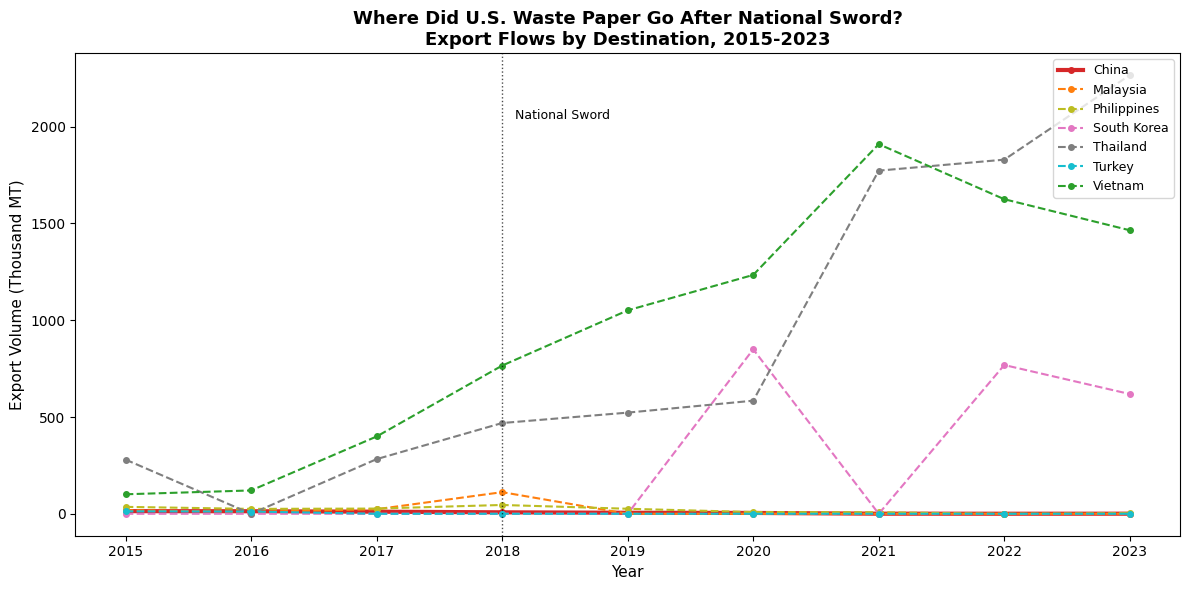

Saved.


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load destination data
dest = pd.read_csv('../data/processed/paper_destinations.csv')

# Pull China from original data for comparison
raw = pd.read_csv('../data/raw/comtrade_raw.csv')
china_paper = raw[(raw['partner_name'] == 'China') & (raw['cmd_code'] == 4707)][['year','net_weight_mt']].copy()
china_paper['partner'] = 'China'

# Combine
combined = pd.concat([
    dest[['year','partner','net_weight_mt']],
    china_paper[['year','partner','net_weight_mt']]
])

# Pivot
pivot = combined.pivot_table(index='year', columns='partner', values='net_weight_mt', aggfunc='sum').fillna(0)
pivot = pivot.sort_index()

# Color map
colors = {
    'China': '#d62728',
    'India': '#1f77b4',
    'Vietnam': '#2ca02c',
    'Malaysia': '#ff7f0e',
    'Indonesia': '#9467bd',
    'Mexico': '#8c564b',
    'South Korea': '#e377c2',
    'Thailand': '#7f7f7f',
    'Philippines': '#bcbd22',
    'Turkey': '#17becf',
}

fig, ax = plt.subplots(figsize=(12, 6))

for country in pivot.columns:
    lw = 3 if country == 'China' else 1.5
    ls = '-' if country == 'China' else '--'
    ax.plot(pivot.index, pivot[country] / 1000,
            label=country, color=colors.get(country, 'gray'),
            linewidth=lw, linestyle=ls, marker='o', markersize=4)

ax.axvline(x=2018, color='black', linestyle=':', linewidth=1, alpha=0.7)
ax.text(2018.1, pivot.max().max() / 1000 * 0.9, 'National Sword', fontsize=9)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Export Volume (Thousand MT)', fontsize=11)
ax.set_title("Where Did U.S. Waste Paper Go After National Sword?\nExport Flows by Destination, 2015-2023",
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, framealpha=0.8)
ax.set_xticks(range(2015, 2024))

plt.tight_layout()
FIG_DIR = os.path.expanduser('~/recycling-analysis/figures')
plt.savefig(f'{FIG_DIR}/04_destination_redirect.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')


In [10]:
rows = fetch_destination_data(764, 'Thailand', years=[2022, 2023])
print(rows)


[{'year': 2022, 'partner': 'Thailand', 'net_weight_mt': 1829876.0, 'fob_value_usd': 362371199.0}, {'year': 2023, 'partner': 'Thailand', 'net_weight_mt': 2266988.0, 'fob_value_usd': 378347232.0}]


In [11]:
import pandas as pd

# Load existing destinations data
dest = pd.read_csv('../data/processed/paper_destinations.csv')

# Remove the bad Thailand rows (0 values from timeouts)
dest = dest[~((dest['partner'] == 'Thailand') & (dest['year'].isin([2022, 2023])))]

# Add correct values
thailand_fix = pd.DataFrame([
    {'year': 2022, 'partner': 'Thailand', 'net_weight_mt': 1829876.0, 'fob_value_usd': 362371199.0},
    {'year': 2023, 'partner': 'Thailand', 'net_weight_mt': 2266988.0, 'fob_value_usd': 378347232.0}
])

dest = pd.concat([dest, thailand_fix], ignore_index=True)
dest.to_csv('../data/processed/paper_destinations.csv', index=False)
print('Fixed. Thailand rows now:')
print(dest[dest['partner'] == 'Thailand'].sort_values('year'))

Fixed. Thailand rows now:
    year   partner  net_weight_mt  fob_value_usd
16  2015  Thailand       279846.0     36630102.0
17  2017  Thailand       282465.0     41951025.0
18  2018  Thailand       469012.0     58317854.0
19  2019  Thailand       522752.0     61630427.0
20  2020  Thailand       584389.0     88354258.0
21  2021  Thailand      1773155.0    359746410.0
32  2022  Thailand      1829876.0    362371199.0
33  2023  Thailand      2266988.0    378347232.0


## Summary: Key Findings

| Finding | Detail |
|---|---|
| China share collapse | Waste paper went from ~70% to ~4% of U.S. exports by weight |
| DiD estimate | Paper fell significantly more than metal scraps post-2018 |
| Policy attribution | Decline is commodity-specific, not a general global demand shock |
| Metals comparison | Copper/Ferrous/Aluminium maintained higher China shares throughout |
| Next step | Destination-level pull to show India/Vietnam redirect |
